# Intro to Clustering in Python

**Author:** Alexander Michels

This notebook walks through the basics of clustering in Python, specifically k-means and DBSCAN.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.vq import kmeans, vq
import seaborn as sb
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

scipy has a `make_blobs` function that will create clustered data for us to explore the methods.

In [2]:
dataset = make_blobs(n_samples=200,
                     centers=6,
                     n_features=2,
                     cluster_std=0.7,
                     random_state=50)

The function returns two objects: the data and the labels for the data (the clusters).

In [3]:
dataset

(array([[-3.62489012e+00, -2.85122683e+00],
        [-1.76544029e+00, -3.43947951e+00],
        [-2.00496566e+00,  5.72321686e+00],
        [-4.79426121e+00, -2.57690914e+00],
        [-1.02950569e-02, -5.23850935e+00],
        [-3.92261218e+00, -2.18491460e+00],
        [-3.22635753e+00, -3.36623495e+00],
        [-8.06615659e-02, -5.58762459e+00],
        [ 5.77630891e+00, -4.07414619e+00],
        [-2.00902100e+00,  1.04924860e+01],
        [-4.98930288e+00, -2.60396845e+00],
        [-2.28459566e+00,  1.02718055e+01],
        [-3.28264426e-01, -4.47704109e+00],
        [ 3.70983667e-01, -6.25583716e+00],
        [-3.18222275e+00, -2.45492473e+00],
        [-5.02586171e+00, -1.86576074e+00],
        [-5.26189764e+00, -1.48375989e+00],
        [-4.20254738e+00, -3.87784041e+00],
        [-4.75040149e+00, -1.47944545e+00],
        [-2.05818278e+00,  9.97156998e+00],
        [ 3.80548715e+00, -4.30741213e+00],
        [ 4.64543765e+00, -4.13932543e+00],
        [ 4.62939472e+00, -3.397

In [4]:
points = dataset[0]  # lets grab the data
labels = dataset[1]  # lets grab the labels

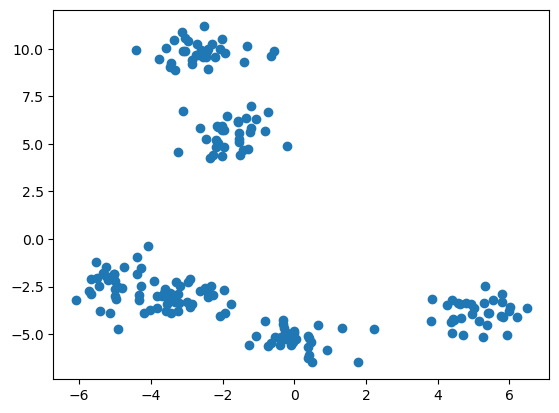

In [5]:
plt.scatter(points[:, 0], points[:, 1])

## k-Means

We can create a k-means model with scipy as well by passing it our data and our guess for how many clusters there are. Documentation on the function: https://docs.scipy.org/doc/scipy-1.13.0/reference/generated/scipy.cluster.vq.kmeans.html#scipy.cluster.vq.kmeans

In [6]:
model = kmeans(points, k_or_guess=7)

The kmeans function returns a k by N array of the centroids and a measure of the fitness called the distortion: https://docs.scipy.org/doc/scipy-1.13.0/reference/generated/scipy.cluster.vq.kmeans.html

In [7]:
model

(array([[-3.07333002, -3.11751345],
        [ 5.76966913, -3.67378685],
        [-4.9916026 , -2.34601241],
        [-1.7721272 ,  5.49998786],
        [ 0.05435988, -5.25331014],
        [ 4.63155291, -4.00991789],
        [-2.61391214,  9.84755885]]),
 0.783536356752581)

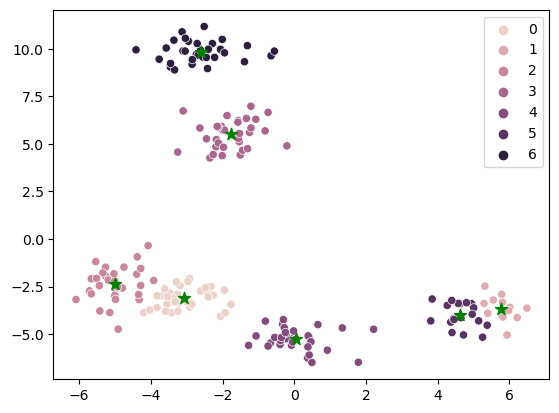

In [8]:
centroids = model[0]  # save the centroids as a variable called centroids
cluster_num = vq(points, centroids)[0]  # get the cluster number

# scatter plot of K-Means cluster
sb.scatterplot(x=points[:, 0],
               y=points[:, 1],
               hue=cluster_num)

# Centroid of the clusters
plt.scatter(centroids[:, 0],
            centroids[:, 1],
            marker='*',
            s=80,
            color='green')

Let's try again with the data not scaled to demonstrate the importance of standardization!

In [9]:
scaled_data = points * [1, 10]

<Axes: >

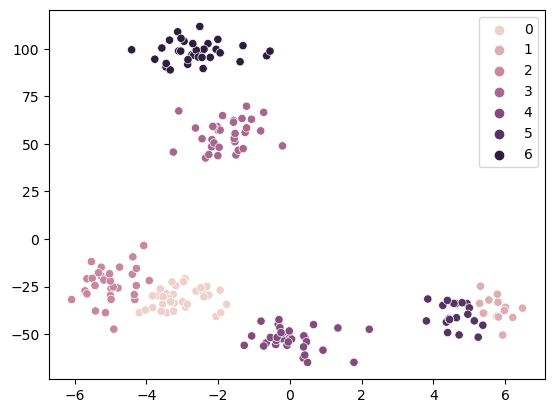

In [10]:
# scatter plot of K-Means cluster
sb.scatterplot(x=scaled_data[:, 0],
               y=scaled_data[:, 1],
               hue=cluster_num)

In [11]:
scaled_model = kmeans(scaled_data, k_or_guess=4)

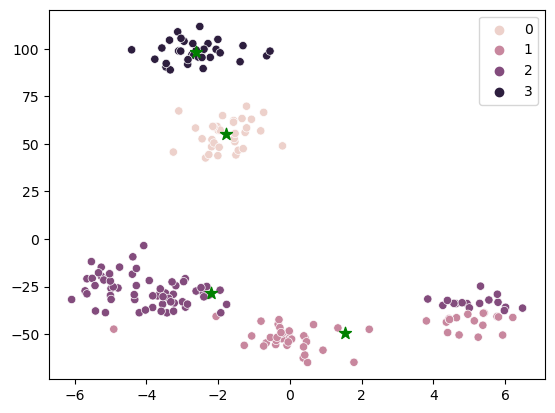

In [12]:
centroids = scaled_model[0]
cluster_num = vq(scaled_data, centroids)[0]  # get the cluster number

# scatter plot of K-Means cluster
sb.scatterplot(x=scaled_data[:, 0],
               y=scaled_data[:, 1],
               hue=cluster_num)

# Centroid of the clusters
plt.scatter(centroids[:, 0],
            centroids[:, 1],
            marker='*',
            s=80,
            color='green')

## DBSCAN

Now we will use a density-based approach called DBSCAN. The following code is adapted from: https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html#sphx-glr-auto-examples-cluster-plot-dbscan-py

DBSCAN documentation: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

In [13]:
# eps is our distance, min_sample is the minimum points to be a cluster
db = DBSCAN(eps=1.2, min_samples=2).fit(points)

With our fitted model, we can get the number of clusters and the "noise points" or outliers.

In [14]:
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 5
Estimated number of noise points: 0


Now we can plot our result:

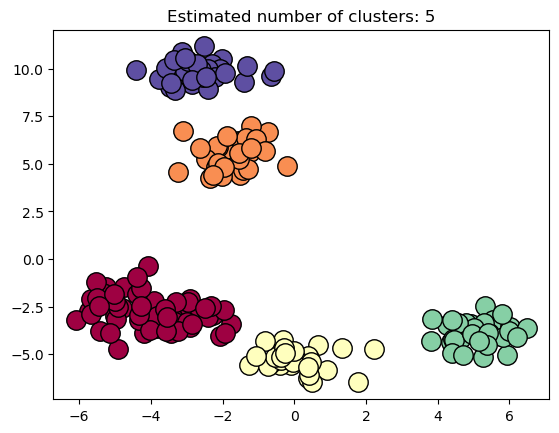

In [15]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = points[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = points[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()